In [2]:
import logging
logging.basicConfig(level=logging.ERROR, format="%(asctime)s %(name)s %(levelname)s %(message)s")

from src.experimenthandling import ExperimentAnalyzer

In [3]:
def load_and_return(experiment: str) -> ExperimentAnalyzer:
    exp = ExperimentAnalyzer(experiment)
    exp.load_models()
    exp.compile_metrics()
    return exp

In [5]:
exp1a = load_and_return('experiment_1a')
exp1b = load_and_return('experiment_1b')
exp1c = load_and_return('experiment_1c')
exp1d = load_and_return('experiment_1d')


==              gcn-graph1-hl1-s42              ==

==              gcn-graph2-hl1-s42              ==

==              gcn-graph3-hl1-s42              ==

==              gcn-graph4-hl1-s42              ==

==             gcn-graph1-hl1-s123              ==

==             gcn-graph2-hl1-s123              ==

==             gcn-graph3-hl1-s123              ==

==             gcn-graph4-hl1-s123              ==

==             gcn-graph1-hl1-s456              ==

==             gcn-graph2-hl1-s456              ==

==             gcn-graph3-hl1-s456              ==

==             gcn-graph4-hl1-s456              ==

==              gat-graph1-hl1-s42              ==

==              gat-graph2-hl1-s42              ==

==              gat-graph3-hl1-s42              ==

==              gat-graph4-hl1-s42              ==

==             gat-graph1-hl1-s123              ==

==             gat-graph2-hl1-s123              ==

==             gat-graph3-hl1-s123              ==

==         

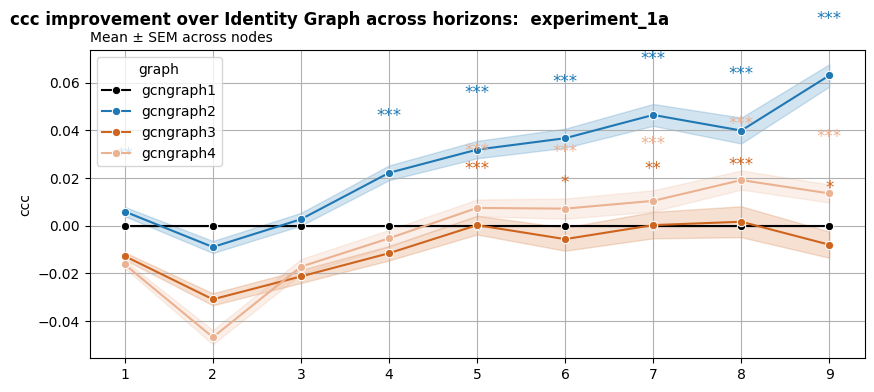

In [ ]:
exp1a.plot_graph_advantage('gcn', 'ccc')
exp1a.plot_graph_advantage('gat', 'ccc')
exp1a.compare_modeltypes('ccc', 'graph1')

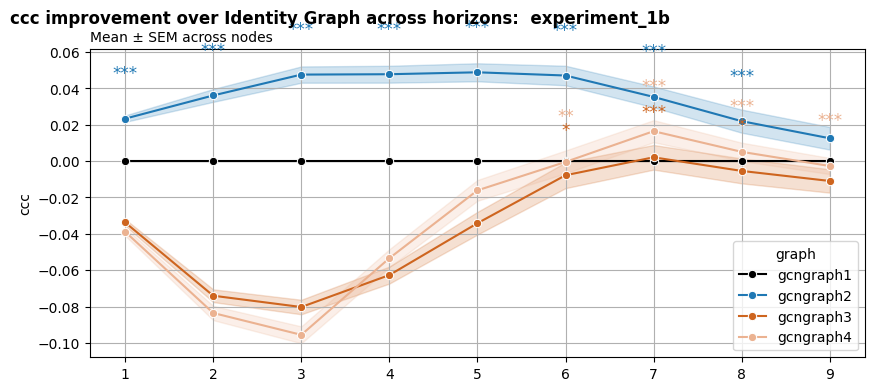

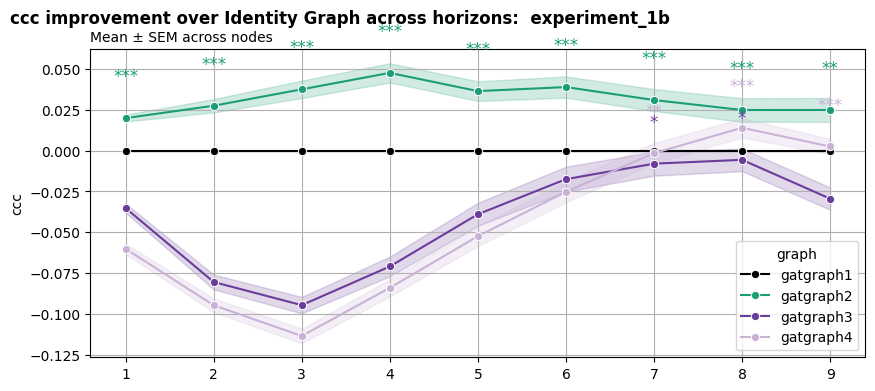

In [ ]:
exp1b.plot_graph_advantage('gcn', 'ccc', titles=False)
exp1b.plot_graph_advantage('gat', 'ccc', titles=False)

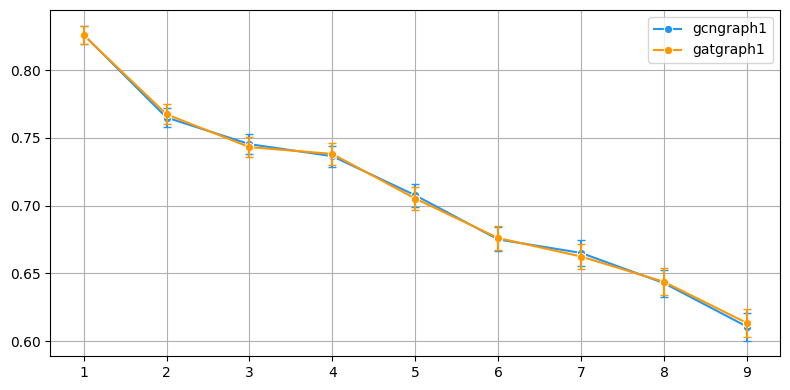

In [ ]:
exp1c.plot_graph_advantage('gcn', 'ccc')
exp1c.plot_graph_advantage('gat', 'ccc')
exp1c.compare_modeltypes('ccc', 'graph1')

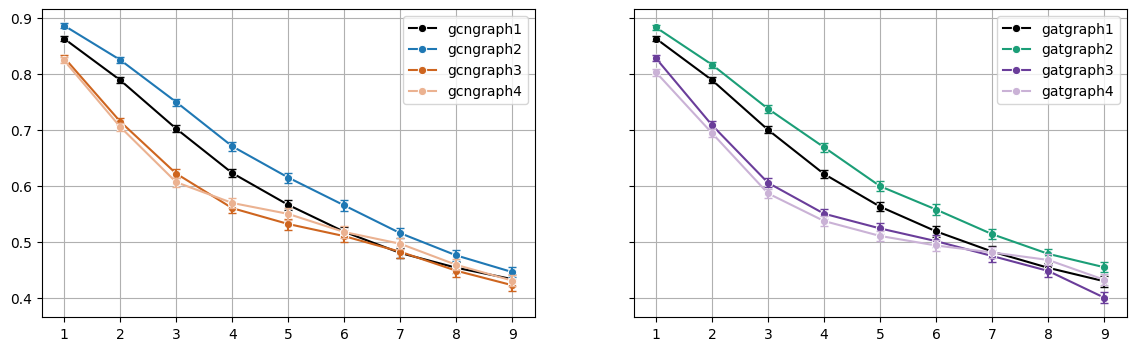

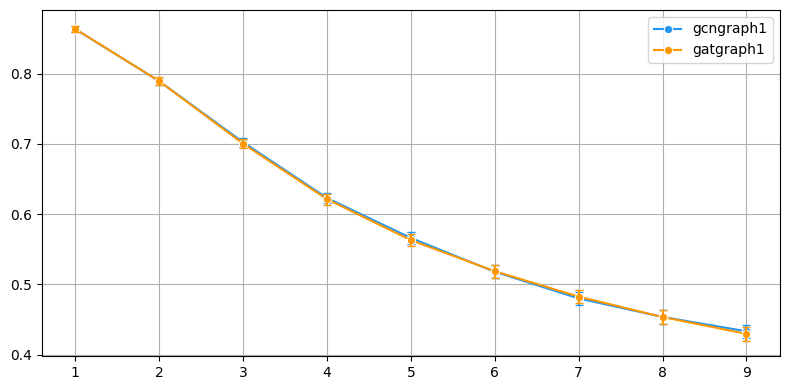

In [ ]:
exp1d.plot_graph_advantage('gcn', 'ccc')
exp1d.plot_graph_advantage('gat', 'ccc')
exp1d.compare_modeltypes('ccc', 'graph1')

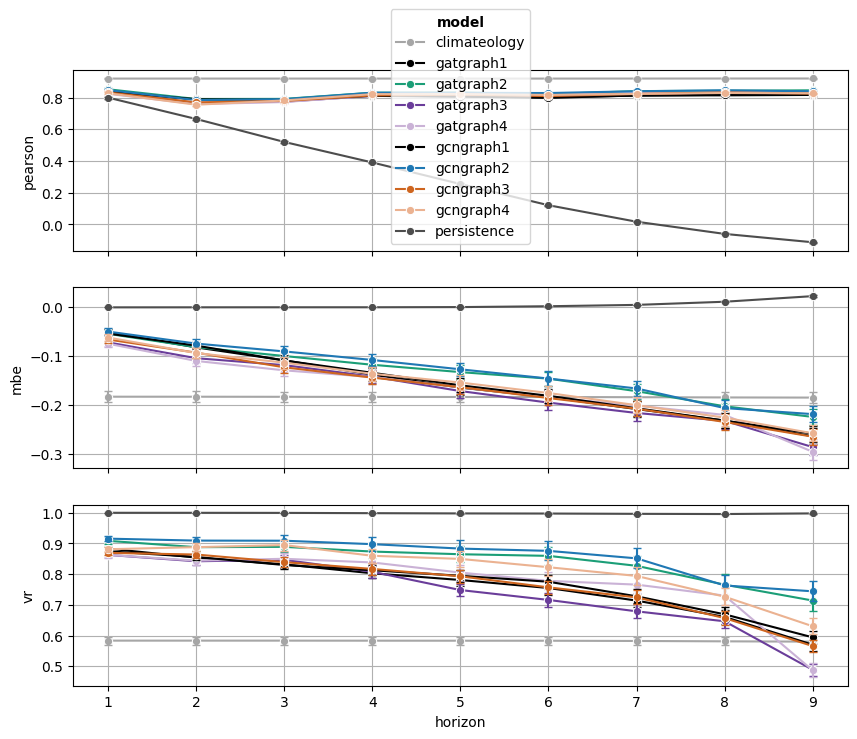

In [49]:
metrics = ['pearson', 'mbe','vr']
import seaborn as sns

fig, axes = plt.subplots(3,1, figsize = (10, 8), sharex=True)
axes        = axes.flatten()


for idx, (ax, metric) in enumerate(zip(axes, metrics)):

    summary     = exp1a.summarize_absolute_metric(metric)
    ax.grid()
    ax.set_ylabel(metric)
    ax.set_xlabel('')

    for ml in summary['model'].unique():

        subset = summary[summary['model'] == ml] 
        sns.lineplot(subset, x = 'hl', y = 'mean', c = exp1a.model_colors[ml], ax = ax, marker = 'o', label = ml)
        ax.errorbar(
            x   =subset['hl'],
            y   =subset['mean'],
            yerr=subset['sem'],
            fmt ='none', 
            capsize=3,
            color = exp1a.model_colors[ml]
        )       

    if idx == 0:
        ax.legend(
                title='model',
                title_fontproperties={'weight': 'bold'}
            )
    else:
        ax.legend_.remove()
        ax.set_xlabel('horizon')



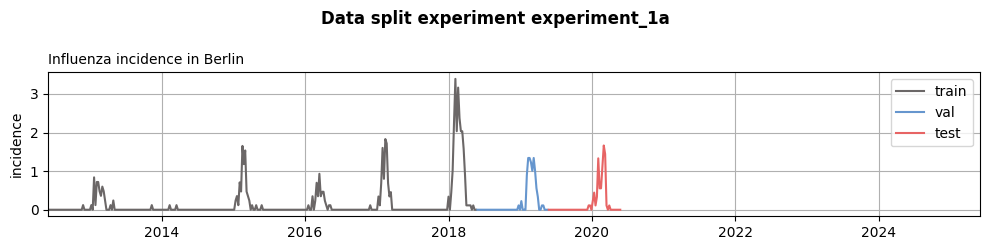

In [6]:
exp1a.plot_datasplit()

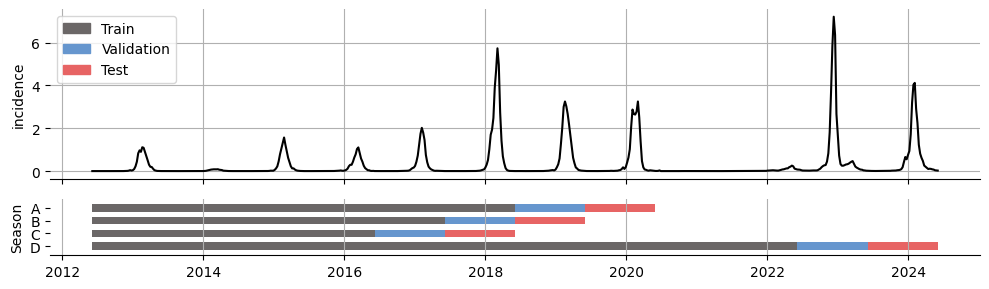

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt 
from matplotlib.axes import Axes 
from matplotlib.figure import Figure
import matplotlib.dates as mdates

import pandas as pd 
from datetime import datetime


axes_min = pd.Timestamp('2012-01-01')
axes_max = pd.Timestamp('2025-01-01')

# min, train/val, val/test, max
datasplits = {}
tags = ['A','B','C','D']

for idx, exp in enumerate([exp1a, exp1b, exp1c, exp1d]):

    datasplits[tags[idx]] = [
        pd.Timestamp(exp.epidataorchestrators[1].data_context.temporal_summary.min_date),
        pd.Timestamp(exp.epidataorchestrators[1].data_context.temporal_summary.split_trainval),
        pd.Timestamp(exp.epidataorchestrators[1].data_context.temporal_summary.split_valtest),
        pd.Timestamp(exp.epidataorchestrators[1].data_context.temporal_summary.max_date)
    ]


line_min = datasplits['A'][0]
line_max = datasplits['D'][-1]

casedata = exp1a.epidataorchestrators[1].data_harmonized.epidata
casedata = casedata.groupby(['timestamp']).agg({'cases':'sum','population_size':'sum'}).reset_index(drop = False)
casedata['incidence'] = casedata['cases'] / casedata['population_size'] *  exp1a.epicfg.incidence_scalar
casedata = casedata[casedata['timestamp']>=line_min]
casedata = casedata[casedata['timestamp']<=line_max]

colors = {
    "train" : "#6B6767",
    "val"   : "#6696CE",
    "test"  : "#E76464",
}


fig, axs           = plt.subplots(2,1, figsize = (10,3), height_ratios=[3,1], sharex= True)
axes: list[Axes]   = axs.flatten()
bar_height = 0.6
axes[1].grid()
for i, (exp, dates) in enumerate(datasplits.items()):

    start       = dates[0]
    train_end   = dates[1]
    val_end     = dates[2]
    end         = dates[3]

    y = 3 - i   # A at top

    axes[1].broken_barh(
        [(mdates.date2num(start),
          mdates.date2num(train_end) - mdates.date2num(start))],
        (y - bar_height/2, bar_height),
        facecolors=colors["train"],
    )

    axes[1].broken_barh(
        [(mdates.date2num(train_end),
          mdates.date2num(val_end) - mdates.date2num(train_end))],
        (y - bar_height/2, bar_height),
        facecolors=colors["val"],
    )

    axes[1].broken_barh(
        [(mdates.date2num(val_end),
          mdates.date2num(end) - mdates.date2num(val_end))],
        (y - bar_height/2, bar_height),
        facecolors=colors["test"],
    )


sns.lineplot(casedata, x = 'timestamp', y = 'incidence', color = 'black', ax = axes[0])
axes[0].grid()


handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors["train"]),
    plt.Rectangle((0, 0), 1, 1, color=colors["val"]),
    plt.Rectangle((0, 0), 1, 1, color=colors["test"]),
]

axes[0].legend(
    handles,
    ["Train", "Validation", "Test"],
    loc="upper left",
)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].spines["left"].set_visible(False)

axes[1].set_yticks([3, 2, 1, 0])
axes[1].set_yticklabels(["A", "B", "C", "D"])
axes[1].set_ylim(-0.7, 3.7)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].spines["left"].set_visible(False)
axes[1].set_ylabel('Season')

axes[1].grid(axis='y', visible=False)   # or True, if you want horizontal separators between rows

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt 
from matplotlib.axes import Axes 
from matplotlib.figure import Figure
import matplotlib.dates as mdates

import pandas as pd 
from datetime import datetime


axes_min = pd.Timestamp('2004-01-01')
axes_max = pd.Timestamp('2016-01-01')

# min, train/val, val/test, max
datasplits = {}
tags = ['A','B','C']

for idx, exp in enumerate([exp4a, exp4b, exp4c]):

    datasplits[tags[idx]] = [
        pd.Timestamp(exp.epidataorchestrators[1].data_context.temporal_summary.min_date),
        pd.Timestamp(exp.epidataorchestrators[1].data_context.temporal_summary.split_trainval),
        pd.Timestamp(exp.epidataorchestrators[1].data_context.temporal_summary.split_valtest),
        pd.Timestamp(exp.epidataorchestrators[1].data_context.temporal_summary.max_date)
    ]


line_min = datasplits['A'][0]
line_max = datasplits['D'][-1]

casedata = exp4a.epidataorchestrators[1].data_harmonized.epidata
casedata = casedata.groupby(['timestamp']).agg({'cases':'sum','population_size':'sum'}).reset_index(drop = False)
casedata['incidence'] = casedata['cases'] / casedata['population_size'] *  exp4a.epicfg.incidence_scalar
casedata = casedata[casedata['timestamp']>=line_min]
casedata = casedata[casedata['timestamp']<=line_max]

colors = {
    "train" : "#6B6767",
    "val"   : "#6696CE",
    "test"  : "#E76464",
}


fig, axs           = plt.subplots(2,1, figsize = (10,3), height_ratios=[3,1], sharex= True)
axes: list[Axes]   = axs.flatten()
bar_height = 0.6
axes[1].grid()
for i, (exp, dates) in enumerate(datasplits.items()):

    start       = dates[0]
    train_end   = dates[1]
    val_end     = dates[2]
    end         = dates[3]

    y = 3 - i   # A at top

    axes[1].broken_barh(
        [(mdates.date2num(start),
          mdates.date2num(train_end) - mdates.date2num(start))],
        (y - bar_height/2, bar_height),
        facecolors=colors["train"],
    )

    axes[1].broken_barh(
        [(mdates.date2num(train_end),
          mdates.date2num(val_end) - mdates.date2num(train_end))],
        (y - bar_height/2, bar_height),
        facecolors=colors["val"],
    )

    axes[1].broken_barh(
        [(mdates.date2num(val_end),
          mdates.date2num(end) - mdates.date2num(val_end))],
        (y - bar_height/2, bar_height),
        facecolors=colors["test"],
    )


sns.lineplot(casedata, x = 'timestamp', y = 'incidence', color = 'black', ax = axes[0])
axes[0].grid()


handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors["train"]),
    plt.Rectangle((0, 0), 1, 1, color=colors["val"]),
    plt.Rectangle((0, 0), 1, 1, color=colors["test"]),
]

axes[0].legend(
    handles,
    ["Train", "Validation", "Test"],
    loc="upper left",
)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].spines["left"].set_visible(False)

axes[1].set_yticks([3, 2, 1, 0])
axes[1].set_yticklabels(["A", "B", "C", "D"])
axes[1].set_ylim(-0.7, 3.7)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].spines["left"].set_visible(False)
axes[1].set_ylabel('Season')

axes[1].grid(axis='y', visible=False)   # or True, if you want horizontal separators between rows

plt.tight_layout()
plt.show()